TrustLine — AI Response Quality, Trust & Access Audit
This notebook ingests a log of TrustLine (banking assistant) query/response pairs and:

Cleans and validates the raw data
Analyzes response quality (hallucination rate, confidence distribution)
Detects identity/access-level mismatches (responses that exceed the requesting user's clearance)
Trains a scikit-learn model to flag likely-hallucinated responses
Trains an equivalent PyTorch neural network for the same task
Summarizes findings in an Insights Report, a secure system prompt, and Responsible AI recommendations
Dataset: data/trustline_queries.csv (100 logged interactions).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

try:
    import torch
    import torch.nn as nn
    TORCH_AVAILABLE = True
except ImportError:
    TORCH_AVAILABLE = False
    print("PyTorch not installed in this environment — install with `pip install torch` to run Section 5.")

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_colwidth', 60)

1. Data Ingestion & Cleaning

In [2]:
df_raw = pd.read_csv('data/trustline_queries.csv')
print(df_raw.shape)
df_raw.info()

(100, 10)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Query_ID               100 non-null    object 
 1   User_Role              100 non-null    object 
 2   User_Query             98 non-null     object 
 3   AI_Response            99 non-null     object 
 4   Contains_PII           100 non-null    object 
 5   Confidence_Score       99 non-null     float64
 6   Hallucination_Flag     100 non-null    object 
 7   Accessibility_Format   100 non-null    object 
 8   Access_Level_Required  100 non-null    object 
 9   Response_Source        99 non-null     object 
dtypes: float64(1), object(9)
memory usage: 7.9+ KB


In [3]:
df = df_raw.copy()
df['User_Role_clean'] = df['User_Role'].astype(str).str.strip().str.capitalize()
df.loc[~df['User_Role_clean'].isin(['Customer','Employee','Admin']), 'User_Role_clean'] = np.nan

before = len(df)
df = df.dropna(subset=['User_Query','AI_Response','Confidence_Score','Response_Source','User_Role_clean']).reset_index(drop=True)
after = len(df)
print(f"Rows before cleaning: {before}")
print(f"Rows after dropping incomplete/unparseable rows: {after}")

for c in ['Contains_PII','Hallucination_Flag','Accessibility_Format']:
    df[c] = df[c].astype(str).str.strip().str.upper().map({'Y':1,'N':0})

df.to_csv('data/trustline_queries_cleaned.csv', index=False)
df.head(3)

Rows before cleaning: 100
Rows after dropping incomplete/unparseable rows: 97


,Query_ID,User_Role,User_Query,AI_Response,Contains_PII,Confidence_Score,Hallucination_Flag,Accessibility_Format,Access_Level_Required,Response_Source,User_Role_clean
0,Q1001,Employee,What is the exact founding date of this bank's mainframe...,"The mainframe system was founded on March 3, 1987, accor...",0,0.55,1,0,Employee,Model-generated only,Employee
1,Q1002,CUSTOMER,Does the bank offer a guaranteed 8% annual return on sav...,"Yes, our Premium Saver plan guarantees an 8% annual retu...",0,0.49,1,1,Customer,Model-generated only,Customer
2,Q1003,CUSTOMER,Why do I need to complete KYC again?,Periodic KYC refresh is mandated pursuant to risk-based ...,0,0.65,0,0,Customer,Verified,Customer


2. Response Quality Analysis

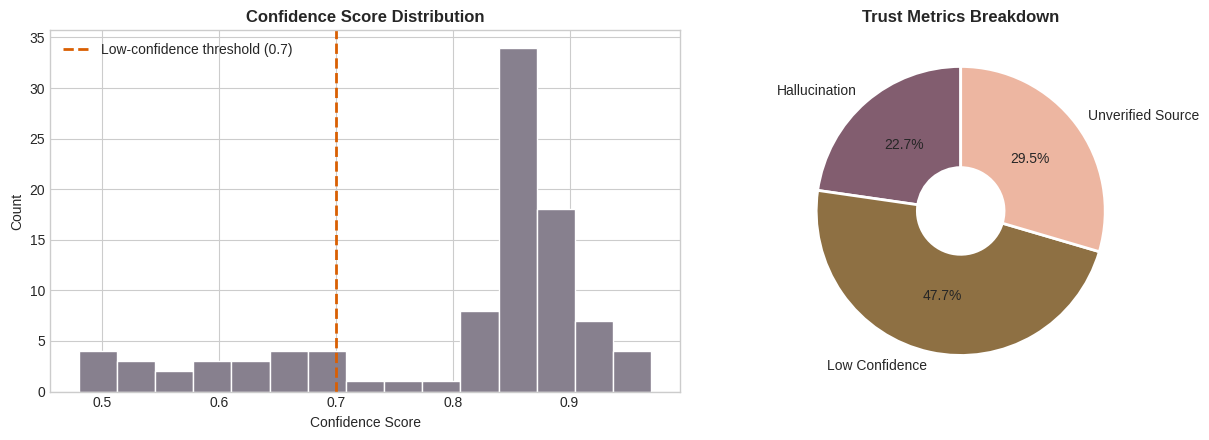

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

halluc_rate = df['Hallucination_Flag'].mean() * 100
low_conf_rate = (df['Confidence_Score'] < 0.7).mean() * 100
unverified_rate = (df['Response_Source'] == 'Model-generated only').mean() * 100

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Score Distribution Histogram
axes[0].hist(df['Confidence_Score'], bins=15, color='#87808e', edgecolor='white')
axes[0].axvline(
    0.7,
    color='#d95f02',
    linestyle='--',
    linewidth=2,
    label='Low-confidence threshold (0.7)',
)
axes[0].set_title(
    'Confidence Score Distribution', fontsize=12, fontweight='bold'
)
axes[0].set_xlabel('Confidence Score')
axes[0].set_ylabel('Count')
axes[0].legend()

# Metrics Chart
labels = ['Hallucination', 'Low Confidence', 'Unverified Source']
sizes = [halluc_rate, low_conf_rate, unverified_rate]
colors = ['#825d6f', '#8e7043', '#edb6a1']

wedges, texts, autotexts = axes[1].pie(
    sizes,
    labels=labels,
    autopct='%1.1f%%',
    startangle=90,
    colors=colors,
    wedgeprops=dict(width=0.7, edgecolor='white', linewidth=2),
)
axes[1].set_title('Trust Metrics Breakdown', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()